<a href="https://colab.research.google.com/github/isahincapiecontacto-netizen/Codigo1/blob/main/EDA_Portafolio_Matplotlib_Seaborn_yfinance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 📊 EDA de un portafolio de activos con Python
### Matplotlib · Seaborn · Pandas · yfinance

**Curso:** Lenguajes de programación  
**Tema:** Visualización y Análisis Exploratorio de Datos (EDA)  
**Caso:** análisis exploratorio de un portafolio de activos financieros

---

## 🎯 ¿Qué vamos a aprender?

Al terminar este notebook podrás:

- reconocer qué es una librería y para qué sirve;
- diferenciar **dato, variable, gráfico e interpretación**;
- crear gráficos básicos con **Matplotlib**;
- utilizar **Seaborn** para explorar distribuciones y relaciones;
- interpretar correctamente los gráficos;
- descargar datos históricos con **yfinance**;
- calcular rendimientos;
- explorar volatilidad, distribución y correlación;
- construir una primera lectura exploratoria de un portafolio.

> **Idea central:** un gráfico no es el resultado del análisis.  
> El gráfico es una herramienta que nos ayuda a **formular preguntas, encontrar patrones y comunicar hallazgos**.



## 🧭 Ruta de la clase

Trabajaremos de manera incremental:

**1. Datos → 2. Variables → 3. Gráfico → 4. Interpretación → 5. EDA → 6. Datos financieros reales**

| Etapa | Pregunta |
|---|---|
| Conceptos | ¿Qué estamos visualizando? |
| Matplotlib | ¿Cómo se construye un gráfico? |
| Seaborn | ¿Cómo exploramos una variable o relación? |
| EDA | ¿Qué patrones encontramos? |
| yfinance | ¿Cómo trabajamos con datos reales? |
| Portafolio | ¿Cómo se comportan conjuntamente los activos? |



# 1. Antes de graficar: pensemos como analistas

Supongamos que tenemos:

| Día | Precio |
|---:|---:|
| 1 | 100 |
| 2 | 103 |
| 3 | 101 |
| 4 | 108 |
| 5 | 112 |

Tenemos dos conceptos diferentes:

### Variable
Una característica que podemos observar o medir.  
Ejemplo: `Precio`.

### Observación
Un valor concreto de una variable.  
Ejemplo: el precio del día 4 es `108`.

### ¿Por qué graficar?

La tabla nos da los valores. El gráfico nos permite **ver la estructura de los datos**.

Por ejemplo:

- ¿el precio está aumentando?
- ¿hay caídas?
- ¿hay cambios bruscos?
- ¿existe una tendencia?

Ese proceso de preguntar, observar y encontrar patrones forma parte del **Análisis Exploratorio de Datos (EDA)**.



# 2. Las librerías que vamos a utilizar

Una **librería** es un conjunto de código reutilizable que otras personas han desarrollado para resolver problemas.

Hoy utilizaremos:

### 🐼 Pandas
Para trabajar con datos tabulares.

### 📈 Matplotlib
Para construir y personalizar visualizaciones.

### 🎨 Seaborn
Para crear visualizaciones estadísticas de forma sencilla y trabajar cómodamente con DataFrames.

### 💰 yfinance
Para obtener datos históricos de activos financieros desde Yahoo Finance.

La relación será:

```text
yfinance
   ↓
datos financieros
   ↓
Pandas
   ↓
transformaciones
   ↓
Matplotlib / Seaborn
   ↓
visualización
   ↓
interpretación
```


In [1]:
# Importamos las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
sns.set_theme(style="whitegrid")

# Para que los gráficos aparezcan dentro del notebook
%matplotlib inline



## ¿Qué significa `import`?

Cuando escribimos:

```python
import matplotlib.pyplot as plt
```

estamos diciendo:

> "Quiero utilizar el módulo `pyplot` de la librería `matplotlib` y voy a llamarlo `plt`."

Por eso posteriormente podemos escribir:

```python
plt.plot(...)
```

El nombre `plt` es un **alias**. No es obligatorio llamarlo así, pero es una convención muy utilizada.

Lo mismo ocurre con:

```python
import seaborn as sns
import pandas as pd
import numpy as np
```



# 3. Nuestro primer gráfico: de una tabla a una visualización

Comencemos con datos muy pequeños para entender **qué hace cada instrucción**.

Tenemos el precio de un activo durante cinco días.


In [2]:
dias = [1, 2, 3, 4, 5]
precios = [100, 103, 101, 108, 112]

datos_ejemplo = pd.DataFrame({
    "Día": dias,
    "Precio": precios
})

datos_ejemplo


,Día,Precio
0,1,100
1,2,103
2,3,101
3,4,108
4,5,112



### Primer intento

Queremos representar:

- eje X → día
- eje Y → precio

La función `plot()` recibe normalmente una serie de valores para X y otra para Y.


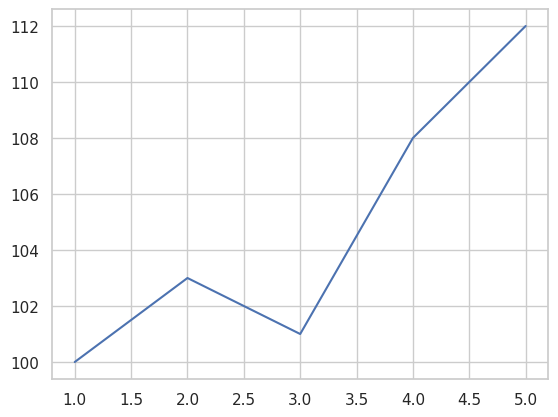

In [3]:
plt.plot(dias, precios)
plt.show()



## 🔎 ¿Qué acaba de ocurrir?

`plt.plot(x, y)`:

- toma los valores de `x`;
- toma los valores de `y`;
- coloca cada par `(x, y)` en el plano;
- conecta los puntos.

En nuestro ejemplo:

```text
(1,100)
(2,103)
(3,101)
(4,108)
(5,112)
```

### ¿Cómo lo interpretamos?

No debemos decir simplemente "el gráfico sube".

Podemos decir:

> **El precio presenta una tendencia general creciente durante el período observado, aunque existe una disminución entre los días 2 y 3.**

Esa segunda frase ya es una **interpretación**.



# 4. Hacer que el gráfico comunique mejor

Un gráfico debe permitir que otra persona entienda rápidamente:

1. **qué está viendo**;
2. **qué representan los ejes**;
3. **qué unidad se está utilizando**;
4. **qué período se está observando**.

Para eso agregamos título y etiquetas.


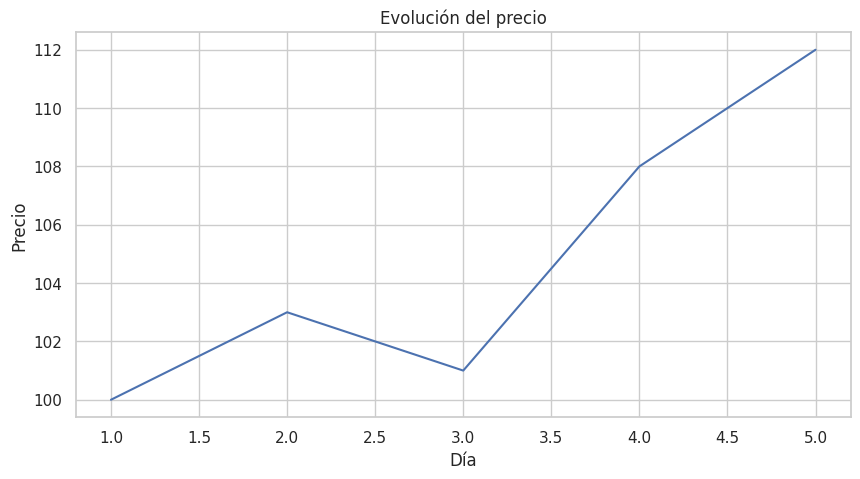

In [4]:
plt.figure(figsize=(10, 5))

plt.plot(dias, precios)

plt.title("Evolución del precio")
plt.xlabel("Día")
plt.ylabel("Precio")

plt.show()



## 🧩 Anatomía de un gráfico

```text
                 TÍTULO
        Evolución del precio

  Y
  ↑
  │             ●
  │          ●
  │     ●
  │        ●
  │  ●
  └──────────────────────→ X
       Día
```

### Elementos principales

- **Título:** comunica qué estamos observando.
- **Eje X:** normalmente representa tiempo o una variable explicativa.
- **Eje Y:** representa la variable que queremos analizar.
- **Línea/puntos:** representan los datos.
- **Leyenda:** identifica las series cuando tenemos varias.



# 5. La interfaz orientada a objetos de Matplotlib

Hasta ahora utilizamos `plt` directamente.

Existe otra forma muy importante:

```python
fig, ax = plt.subplots()
```

Aquí aparecen dos objetos:

### `fig`
Es la **figura completa**, el espacio donde estará nuestro gráfico.

### `ax`
Es el **área de ejes** donde realmente dibujamos.

Una forma sencilla de imaginarlo:

```text
Figure
┌─────────────────────────────┐
│                             │
│       Axes                  │
│     ┌───────────────┐       │
│     │   gráfico     │       │
│     │               │       │
│     └───────────────┘       │
│                             │
└─────────────────────────────┘
```


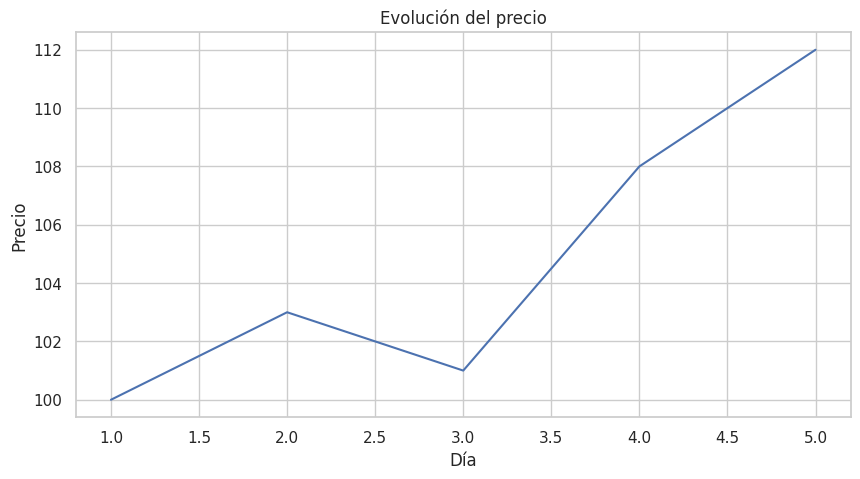

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dias, precios)

ax.set_title("Evolución del precio")
ax.set_xlabel("Día")
ax.set_ylabel("Precio")

plt.show()



### ¿Por qué aprender esta forma?

Cuando los gráficos se vuelven más complejos, trabajar con `fig` y `ax` nos da mayor control.

Por ejemplo, podemos tener varios gráficos dentro de una misma figura y controlar cada eje por separado.

**Regla práctica para la clase:**

- `plt.plot()` → muy útil para comenzar.
- `fig, ax = plt.subplots()` → recomendable cuando queremos construir gráficos de forma más estructurada.



# 6. Gráficos de varias series

Ahora supongamos que tenemos tres activos.


In [6]:
precios_portafolio = pd.DataFrame({
    "AAPL": [100, 103, 101, 108, 112],
    "MSFT": [100, 102, 104, 106, 109],
    "NVDA": [100, 98, 105, 110, 120]
}, index=[1, 2, 3, 4, 5])

precios_portafolio


,AAPL,MSFT,NVDA
1,100,100,100
2,103,102,98
3,101,104,105
4,108,106,110
5,112,109,120



Si graficamos los precios directamente, podemos comparar las series.

Pero aparece un problema importante:

> ¿Cómo comparamos activos que originalmente tienen precios diferentes?

Por ahora nuestros datos comienzan todos en 100. Esto es intencional: queremos concentrarnos en la **forma de la serie** antes de introducir los rendimientos.


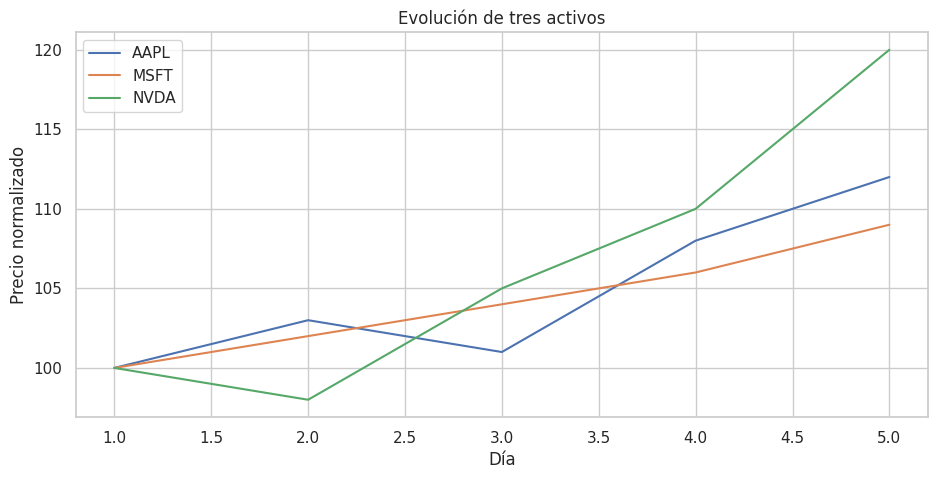

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(precios_portafolio.index, precios_portafolio["AAPL"], label="AAPL")
ax.plot(precios_portafolio.index, precios_portafolio["MSFT"], label="MSFT")
ax.plot(precios_portafolio.index, precios_portafolio["NVDA"], label="NVDA")

ax.set_title("Evolución de tres activos")
ax.set_xlabel("Día")
ax.set_ylabel("Precio normalizado")
ax.legend()

plt.show()



## 🧠 Interpretación

Observe primero, **después interprete**.

Preguntas:

1. ¿Cuál serie termina más arriba?
2. ¿Cuál presenta más cambios?
3. ¿Hay momentos en los que dos activos se mueven en direcciones diferentes?
4. ¿Podemos concluir cuál es "mejor" solamente con este gráfico?

La última pregunta es importante:

> **No.** Un gráfico puede mostrar comportamiento histórico, pero no convierte automáticamente ese comportamiento en una recomendación de inversión.



# 7. Seaborn: visualización orientada al análisis estadístico

Seaborn está construido sobre Matplotlib y facilita muchos gráficos estadísticos.

Una ventaja importante es que puede trabajar directamente con estructuras de Pandas.

Vamos a utilizar primero un **histograma**.


In [8]:
# Generamos una muestra sencilla de rendimientos

np.random.seed(42)

rendimientos_ejemplo = np.random.normal(
    loc=0.001,
    scale=0.02,
    size=500
)

rendimientos_ejemplo[:10]


array([ 0.01093428, -0.00176529,  0.01395377,  0.0314606 , -0.00368307,
       -0.00368274,  0.03258426,  0.01634869, -0.00838949,  0.0118512 ])


## ¿Qué pregunta responde un histograma?

Un histograma permite observar cómo se distribuyen los valores.

Por ejemplo:

> ¿En qué rango se concentran los rendimientos?


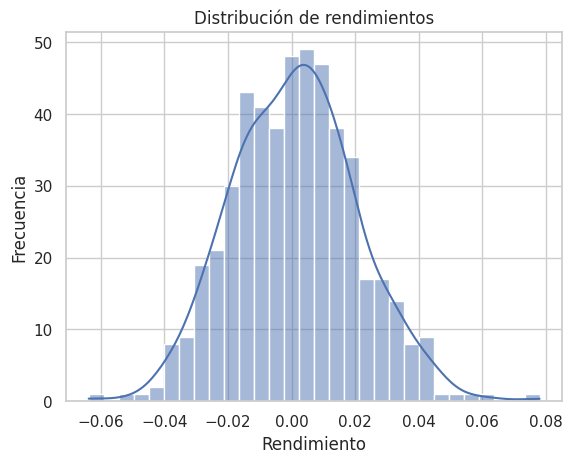

In [9]:
sns.histplot(
    rendimientos_ejemplo,
    bins=30,
    kde=True
)

plt.title("Distribución de rendimientos")
plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")

plt.show()



## 🔎 ¿Cómo interpretar un histograma?

Observemos:

### Centro
¿Dónde se concentran la mayoría de los valores?

### Dispersión
¿Qué tan extendidos están los datos?

### Colas
¿Hay valores alejados del centro?

### Forma
¿La distribución parece simétrica o presenta algún sesgo?

**Importante:** la forma del histograma depende de decisiones como el número de `bins`. No debemos interpretar cada detalle visual como una propiedad exacta de los datos.



# 8. Boxplot: detectar dispersión y valores extremos

Un boxplot resume visualmente una distribución.

Conceptualmente muestra:

- mediana;
- cuartiles;
- rango intercuartílico;
- posibles valores extremos.



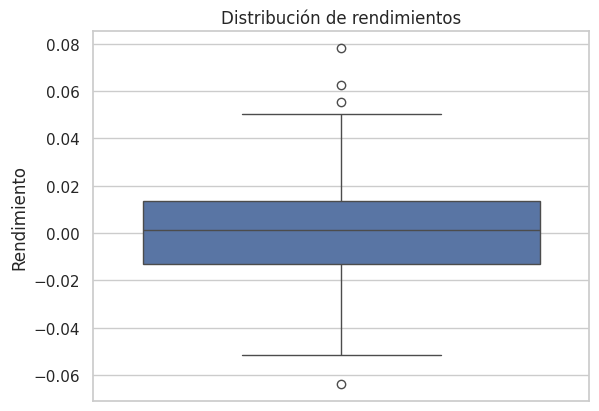

In [10]:
sns.boxplot(y=rendimientos_ejemplo)

plt.title("Distribución de rendimientos")
plt.ylabel("Rendimiento")

plt.show()



### Preguntas para interpretar

- ¿Dónde está la mediana?
- ¿Qué tan grande es la caja?
- ¿Qué tan largos son los bigotes?
- ¿Aparecen observaciones alejadas?

El objetivo no es memorizar la forma del dibujo.

El objetivo es poder decir:

> "La distribución presenta mayor/menor dispersión..."

y justificarlo a partir del gráfico.



# 9. Scatter plot: estudiar relaciones

Ahora queremos estudiar dos variables.

Por ejemplo:

> ¿Los cambios diarios de AAPL y MSFT tienden a ocurrir en la misma dirección?

Para eso usamos un **scatter plot**.

Cada punto representa una observación.


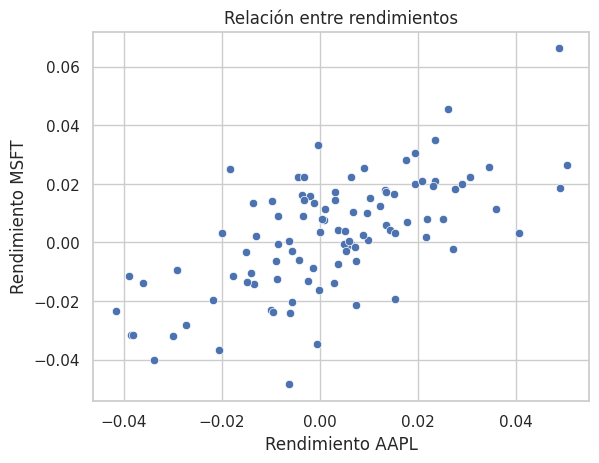

In [11]:
np.random.seed(10)

aapl = np.random.normal(0.001, 0.02, 100)
msft = aapl * 0.6 + np.random.normal(0, 0.015, 100)

sns.scatterplot(x=aapl, y=msft)

plt.title("Relación entre rendimientos")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()



## Interpretación

Buscamos patrones:

- nube ascendente → posible relación positiva;
- nube descendente → posible relación negativa;
- nube sin orientación clara → relación lineal débil o inexistente.

Pero recuerda:

> **Correlación no significa causalidad.**

Dos variables pueden moverse juntas sin que una sea la causa de la otra.



# 10. Correlación y mapa de calor

La correlación permite cuantificar la relación lineal entre dos variables.

En Python:

```python
df.corr()
```

produce una matriz de correlaciones.

Valores cercanos a:

- `1` → relación lineal positiva fuerte;
- `0` → relación lineal débil;
- `-1` → relación lineal negativa fuerte.

Veámoslo visualmente.


In [12]:
datos_rendimientos = pd.DataFrame({
    "AAPL": aapl,
    "MSFT": msft,
    "NVDA": aapl * 0.3 + np.random.normal(0, 0.025, 100)
})

correlacion = datos_rendimientos.corr()

correlacion


,AAPL,MSFT,NVDA
AAPL,1.000000,0.648544,0.207646
MSFT,0.648544,1.000000,0.205384
NVDA,0.207646,0.205384,1.000000


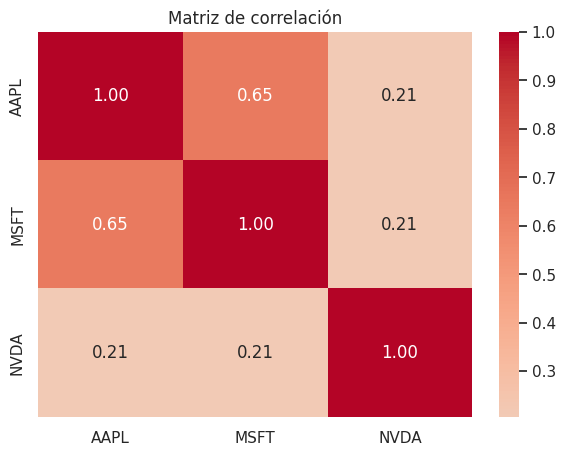

In [13]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()



## 🧠 Interpretar el heatmap

La matriz permite responder rápidamente:

> ¿Qué activos tienen comportamientos más similares?

Pero debemos tener cuidado:

- la correlación mide principalmente **relación lineal**;
- una correlación histórica no garantiza que se mantenga igual;
- correlación no significa causalidad;
- el período elegido afecta el resultado.

Para un análisis financiero serio también debemos considerar el período, frecuencia, calidad de datos y contexto del mercado.



# 11. Ahora sí: datos reales con yfinance 💰

Hasta este momento utilizamos datos pequeños o simulados para entender la visualización.

Ahora vamos a trabajar con datos reales.

Instalación, si el entorno todavía no tiene la librería:

```bash
pip install yfinance
```

Importamos:


In [14]:
import yfinance as yf



## ¿Qué activos vamos a estudiar?

Usaremos como ejemplo:

- `AAPL` — Apple
- `MSFT` — Microsoft
- `GOOGL` — Alphabet
- `AMZN` — Amazon
- `NVDA` — NVIDIA

Los símbolos son **tickers**, identificadores utilizados para localizar activos en los mercados.

> Los datos obtenidos mediante servicios externos pueden cambiar con el tiempo. Para una clase de EDA esto es útil: cada estudiante puede obtener una fotografía diferente del período consultado.


In [15]:
activos = []

precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()


[*********************100%***********************]  5 of 5 completed


Price            Close                                                 \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA   
Date                                                                    
2024-01-02  183.404037  149.929993  136.867615  363.117889  48.028793   
2024-01-03  182.030762  148.470001  137.610550  362.853607  47.431526   
2024-01-04  179.718933  144.570007  135.104385  360.249146  47.859283   
2024-01-05  178.997711  145.240005  134.450592  360.063171  48.955101   
2024-01-08  183.324966  149.100006  137.531296  366.858093  52.101978   

Price             High                                                 ...  \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA  ...   
Date                                                                   ...   
2024-01-02  186.170316  152.380005  138.135548  368.042749  49.152535  ...   
2024-01-03  183.641134  151.050003  138.313864  365.458011  48.044747  ...   
2024-01-04  180.884713  147.380005  137.848280  365.301292  48.359832  ...   
2024-01-05  180.558682  146.589996  135.867121  364.283080  49.403801  ...   
2024-01-08  183.364493  149.399994  137.699692  367.357443  52.123918  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA   
Date                                                                    
2024-01-02  184.895845  151.539993  137.244038  366.045381  49.101684   
2024-01-03  182.001124  149.199997  135.956293  361.296845  47.347769   
2024-01-04  179.956033  145.589996  137.115249  362.922093  47.628948   
2024-01-05  179.797968  144.690002  135.460982  361.257672  48.321938   
2024-01-08  179.896761  146.740005  135.005329  361.580743  49.368903   

Price         Volume                                           
Ticker          AAPL      AMZN     GOOGL      MSFT       NVDA  
Date                                                           
2024-01-02  82488700  47339400  23711200  25258600  411254000  
2024-01-03  58414500  49425500  24212100  23083500  320896000  
2024-01-04  71983600  56039800  27137700  20901500  306535000  
2024-01-05  62379700  45153100  22513900  21004600  415039000  
2024-01-08  59144500  46757100  21404000  23134000  642510000  

[5 rows x 25 columns]

In [25]:
activos = ["AAPL", "AMZN", "GOOGL","MSFT", "NVDA"]

datos = yf.download(
    activos,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=False
)

precios = datos["Close"]
precios.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-02,75.087502,94.900497,68.433998,160.619995,5.99775
2020-01-03,74.357498,93.748497,68.075996,158.619995,5.90175
2020-01-06,74.949997,95.143997,69.890503,159.029999,5.92650
2020-01-07,74.597504,95.343002,69.755501,157.580002,5.99825
2020-01-08,75.797501,94.598503,70.251999,160.089996,6.00950



# 12. Antes de graficar: conozcamos nuestros datos

Una regla fundamental de EDA:

> **No empieces a graficar sin conocer primero el DataFrame.**

Preguntas básicas:

- ¿cuántas filas tenemos? R/ 5 filas
- ¿cuántas columnas? R/ 6 columnas
- ¿qué tipo de datos? R/ Float
- ¿hay valores faltantes?  R/ No hay valores faltantes
- ¿qué período cubren? R/ De 2020-01-02 a 2020-01-08


In [27]:
print("Dimensiones:", precios.shape)

precios.info()


Dimensiones: (1258, 5)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1258 non-null   float64
 1   AMZN    1258 non-null   float64
 2   GOOGL   1258 non-null   float64
 3   MSFT    1258 non-null   float64
 4   NVDA    1258 non-null   float64
dtypes: float64(5)
memory usage: 59.0 KB


In [28]:
precios.describe()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,154.108800,146.713811,119.075610,294.338092,38.471407
std,41.520877,32.004698,32.453265,80.167080,38.228581
min,56.092499,81.820000,52.706501,135.419998,4.910000
25%,129.624996,121.000000,93.947502,235.755001,13.608687
50%,152.805000,153.872498,119.699997,283.504990,21.261499
75%,178.850006,170.000000,141.107998,339.659996,45.646250
max,259.019989,232.929993,196.660004,467.559998,148.880005


In [30]:
precios.isna().sum()


,0
Ticker,
AAPL,0
AMZN,0
GOOGL,0
MSFT,0
NVDA,0



### 🧪 Mini-reto

Antes de continuar, responde:

1. ¿Cuántas observaciones tenemos? R/ 5 observaciones
2. ¿Cuál es la primera fecha?  R/ 2 de enero de 2020
3. ¿Cuál es la última fecha? R/ 8 de enero de 2020
4. ¿Existen valores faltantes? R/ No hay valores faltantes
5. ¿Qué representa cada nivel de columnas? R/ Representa cada uno de los tickers

**No continúes hasta intentar responderlas.**



# 13. Seleccionar el precio de cierre

`yfinance` devuelve varias variables para cada activo, entre ellas:

- Open
- High
- Low
- Close
- Volume

Para nuestro primer análisis utilizaremos **Close**, el precio de cierre ajustado según la configuración utilizada.



In [34]:
cierre = precios

cierre.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-02,75.087502,94.900497,68.433998,160.619995,5.99775
2020-01-03,74.357498,93.748497,68.075996,158.619995,5.90175
2020-01-06,74.949997,95.143997,69.890503,159.029999,5.92650
2020-01-07,74.597504,95.343002,69.755501,157.580002,5.99825
2020-01-08,75.797501,94.598503,70.251999,160.089996,6.00950



## Visualicemos los precios

Primera pregunta del EDA:

> **¿Cómo evolucionaron los precios de los activos durante el período?**
R/ Análisis de la evolución en el período
Tendencia general: Fue un período de relativa estabilidad con fluctuaciones moderadas de corto plazo.

Mejor desempeño: GOOGL registró el mayor avance (+2.66%), pasando de $68.43 el 2 de enero a un máximo de $70.25 el 8 de enero.

Retrocesos: MSFT y AMZN experimentaron caídas leves alrededor del -0.32% y -0.33%, mostrando correcciones puntuales a lo largo de esos 5 días (como el descenso del 3 al 7 de enero en MSFT).

Resiliencia: AAPL y NVDA recuperaron las pérdidas sufridas entre el 3 y el 7 de enero, cerrando el período con saldo positivo respecto al precio inicial.

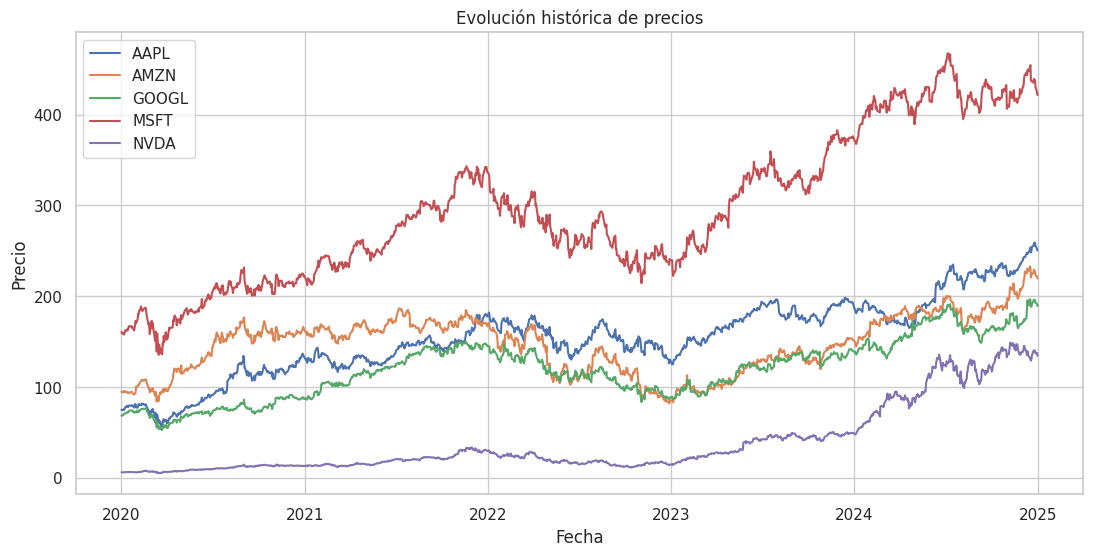

In [36]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()

plt.show()



## ⚠️ Una dificultad de comparar precios

AAPL puede tener un precio nominal diferente de NVDA, MSFT, etc.

Eso hace que comparar las alturas directamente pueda ser engañoso.

Una solución sencilla para estudiar **crecimiento relativo** es normalizar las series.

Por ejemplo:

```python
precio_normalizado = precio / precio_inicial * 100
```

Así todos comienzan en 100.


In [37]:
cierre_normalizado = cierre / cierre.iloc[0] * 100

cierre_normalizado.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-02,100.000000,100.000000,100.000000,100.000000,100.000000
2020-01-03,99.027796,98.786097,99.476866,98.754825,98.399404
2020-01-06,99.816874,100.256584,102.128335,99.010088,98.812055
2020-01-07,99.347431,100.466283,101.931062,98.107338,100.008340
2020-01-08,100.945562,99.681778,102.656575,99.670029,100.195910


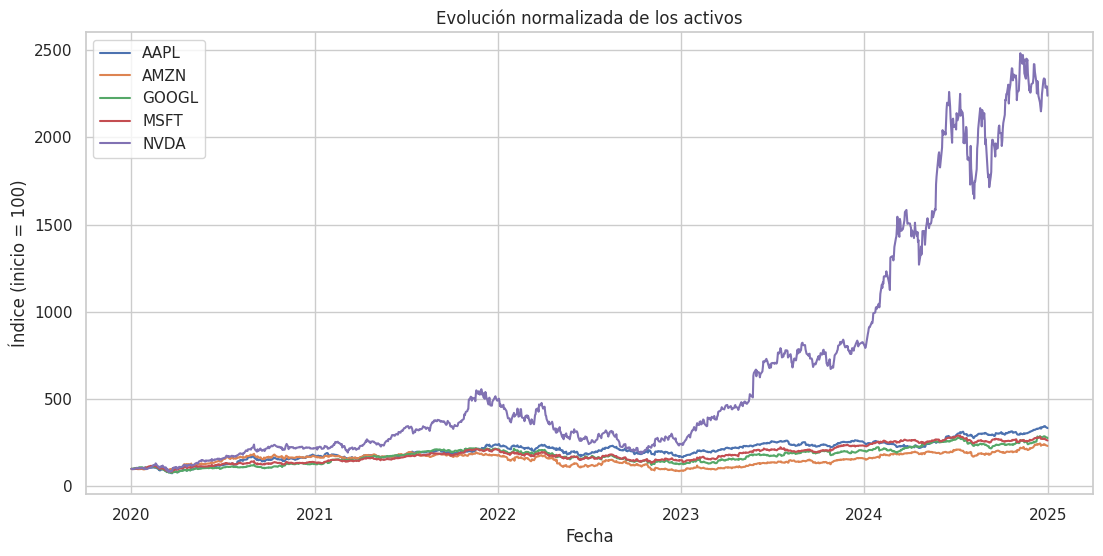

In [38]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Evolución normalizada de los activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()



### ¿Qué pregunta responde este gráfico?

No responde:

> "¿Cuál tiene el precio más alto?"

Responde mejor:

> **"¿Cómo cambió cada activo respecto a su propio punto inicial?"**

Esta distinción es fundamental en análisis de datos financieros.



# 14. Rendimientos: transformar los precios

En análisis financiero suele ser útil estudiar **rendimientos** en lugar de precios.

Un rendimiento porcentual simple entre dos períodos puede calcularse como:

\[
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
\]

En Pandas podemos obtenerlo con:

```python
pct_change()
```


In [39]:
rendimientos = cierre.pct_change()

rendimientos.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009722,-0.012139,-0.005231,-0.012452,-0.016006
2020-01-06,0.007968,0.014886,0.026654,0.002585,0.004194
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.012107
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.001876



El primer registro normalmente será `NaN` porque no tenemos un precio anterior con el cual compararlo.

Eliminemos esos valores para las visualizaciones que lo necesiten.


In [40]:
rendimientos = rendimientos.dropna()

rendimientos.head()


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2020-01-03,-0.009722,-0.012139,-0.005231,-0.012452,-0.016006
2020-01-06,0.007968,0.014886,0.026654,0.002585,0.004194
2020-01-07,-0.004703,0.002092,-0.001932,-0.009118,0.012107
2020-01-08,0.016086,-0.007809,0.007118,0.015928,0.001876
2020-01-09,0.021241,0.004799,0.010498,0.012493,0.010983



# 15. EDA de los rendimientos

### Pregunta 1
**¿Cómo se comportan los rendimientos a través del tiempo?**

R/ Comportamiento y Patrones Clave
Ajuste inicial coordinado (3 de enero):
Todos los activos iniciaron el período con rendimientos negativos, destacando NVDA (-1.60%) y MSFT (-1.25%) con las mayores caídas.

Rebote generalizado (6 de enero):
El mercado reaccionó al alza en todos los fijos. GOOGL registró el mayor rendimiento diario de toda la muestra con un +2.67%, seguido por AMZN (+1.49%).

Inercia alcista hacia el final del período (8 y 9 de enero):
A partir del 8 de enero, la mayoría de los activos retomaron terreno positivo. El 9 de enero fue un día verde sincronizado para las 5 empresas, impulsado por AAPL (+2.12%), MSFT (+1.25%) y NVDA (+1.10%).

Comportamiento acumulado del período:

AAPL y GOOGL mantuvieron la tendencia alcista más constante en los últimos días del período.

AMZN fue el activo con comportamiento más heterogéneo (alternando días positivos y negativos sin una dirección clara al cierre).

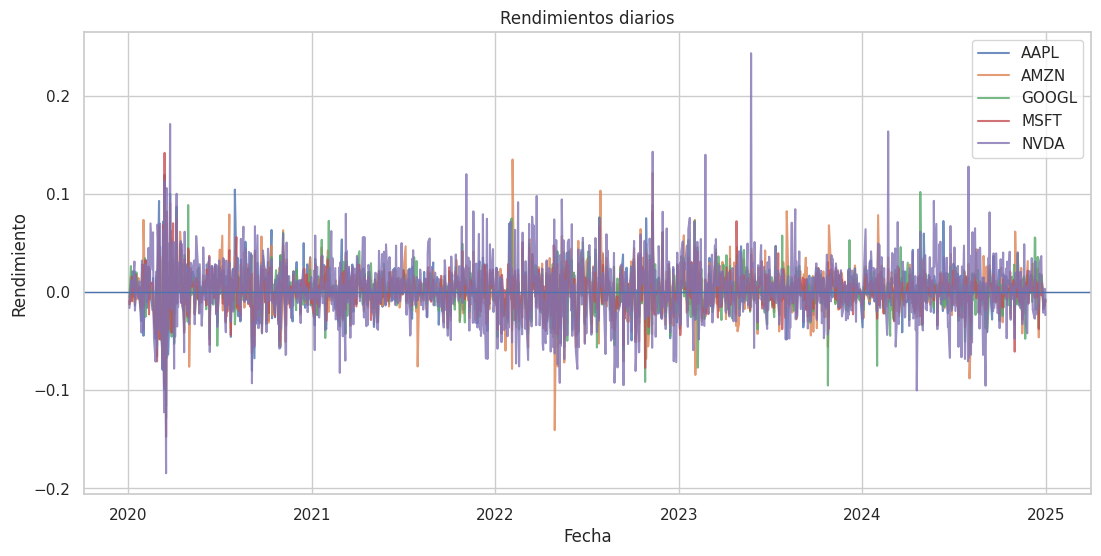

In [41]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()

plt.show()



### Interpretación

La línea horizontal en cero nos ayuda a distinguir:

- valores positivos → rendimiento positivo;
- valores negativos → rendimiento negativo.

Busca:

- períodos de mayor variabilidad;
- movimientos extremos;
- momentos donde varios activos caen simultáneamente;
- diferencias entre activos.

**No confundas variabilidad con rendimiento.**

Un activo puede tener grandes movimientos hacia arriba y hacia abajo y terminar cerca del punto inicial.



# 16. Distribución de rendimientos

Ahora usamos Seaborn para estudiar una variable desde otro ángulo.

Pregunta:

> **¿Cómo se distribuyen los rendimientos diarios de cada activo?**

Hallazgos sobre la Distribución
Rango de Dispersión: En esta muestra de 5 días, los rendimientos oscilan entre un mínimo de -1.60% (NVDA el 3 de enero) y un máximo de +2.67% (GOOGL el 6 de enero).

Asimetría Positiva (Right-Skewed): Activos como AAPL y GOOGL muestran una distribución con sesgo hacia la derecha, acumulando más días con retornos positivos marcados (+1% a +2.67%) que pérdidas profundas.

Agrupación en Torno a Cero: La mayoría de las observaciones se concentran en el rango de [-0.5%, +1.5%], lo cual refleja una baja volatilidad general para el conjunto en ese periodo corto.


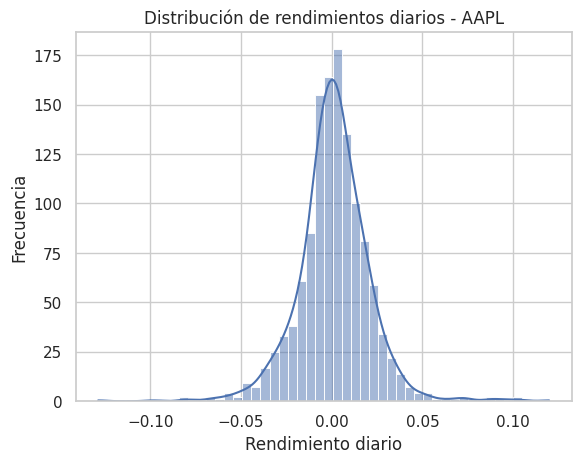

In [42]:
sns.histplot(
    data=rendimientos,
    x="AAPL",
    bins=50,
    kde=True
)

plt.title("Distribución de rendimientos diarios - AAPL")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()



## 🧪 Cambia el activo

Modifica `"AAPL"` por:

```python
"MSFT"
"GOOGL"
"AMZN"
"NVDA"
```

### Pregunta

¿Qué diferencias observas entre las distribuciones?

No busques solamente cuál "se ve mejor".

Describe:

- centro;
- dispersión;
- valores extremos;
- forma de la distribución.



# 17. Comparar la dispersión con un boxplot

Ahora podemos comparar todos los activos simultáneamente.


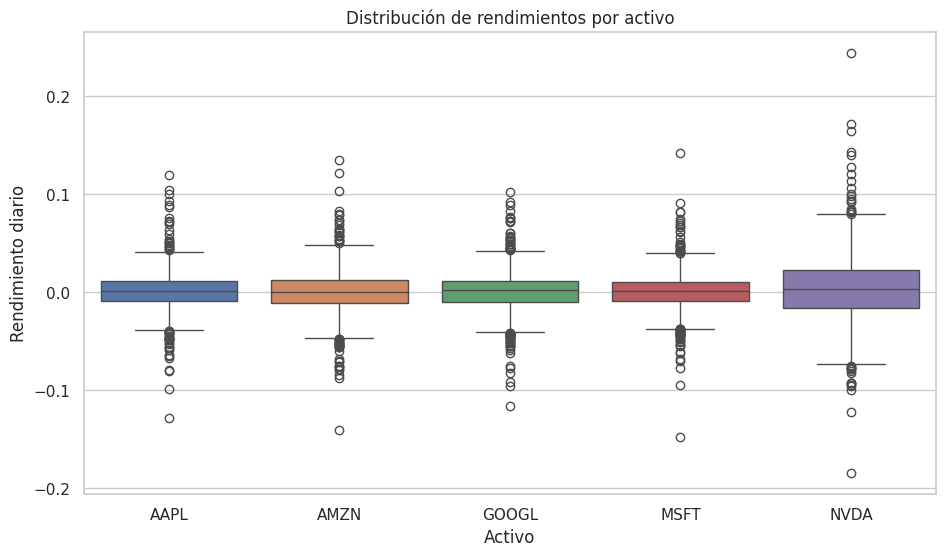

In [43]:
plt.figure(figsize=(11, 6))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")

plt.show()



### Preguntas de análisis

1. ¿Qué activos muestran mayor dispersión?
2. ¿Qué activos presentan más observaciones alejadas?
3. ¿Las medianas están cerca de cero?
4. ¿Qué información perderíamos si solo observáramos el precio?

Aquí aparece una idea importante:

> **Una buena visualización permite comparar una propiedad concreta de los datos.**

R/ ¿Qué activos muestran mayor dispersión?
GOOGL y AAPL presentan la mayor dispersión en su rango de rendimientos. GOOGL abarca desde un mínimo de -0.52% hasta un máximo de +2.67% (un rango de 3.19 puntos porcentuales), mientras que AAPL va de -0.97% a +2.12% (rango de 3.09 p.p.), reflejando fluctuaciones diarias más amplias que activos como AMZN o NVDA en el mismo periodo.

¿Qué activos presentan más observaciones alejadas?
GOOGL y AAPL muestran los valores más alejados del centro de la distribución. GOOGL registró un pico destacado del +2.67% el 6 de enero, y AAPL se alejó hacia la derecha con un +2.12% el 9 de enero, separándose significativamente del promedio general del grupo.

¿Las medianas están cerca de cero?
Sí. En todos los activos, la mediana de los rendimientos diarios se sitúa muy cercana al 0% (registrando valores medios entre +0.05% y +0.62%). Esto es habitual en retornos diarios de renta variable a corto plazo, donde los días con retornos positivos y negativos tienden a equilibrarse en torno a cero.

¿Qué información perderíamos si solo observáramos el precio?
Si solo observáramos el precio en dólares, perderíamos:

Comparabilidad directa: No podríamos comparar el desempeño relativo entre activos de precios muy distantes (por ejemplo, comparar una acción de $6 USD como NVDA con una de $160 USD como MSFT).

Estacionariedad: Los precios absolutos suelen tener tendencias de largo plazo (no son estacionarios), mientras que los rendimientos permiten evaluar la volatilidad, la simetría y el riesgo diario de forma estandarizada.

Magnitud del impacto: Un cambio de $1 USD representa una variación porcentual mínima para un activo costoso, pero un impacto masivo para un activo de bajo precio.


# 18. Matriz de correlación del portafolio

Ahora llegamos a una de las visualizaciones más importantes para nuestro caso.

Pregunta:

> **¿Cómo se relacionan los rendimientos de los activos entre sí?**


In [44]:
correlacion = rendimientos.corr()

correlacion


Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Ticker,,,,,
AAPL,1.000000,0.591883,0.648698,0.748121,0.606278
AMZN,0.591883,1.000000,0.647112,0.678666,0.579749
GOOGL,0.648698,0.647112,1.000000,0.746044,0.594123
MSFT,0.748121,0.678666,0.746044,1.000000,0.682262
NVDA,0.606278,0.579749,0.594123,0.682262,1.000000


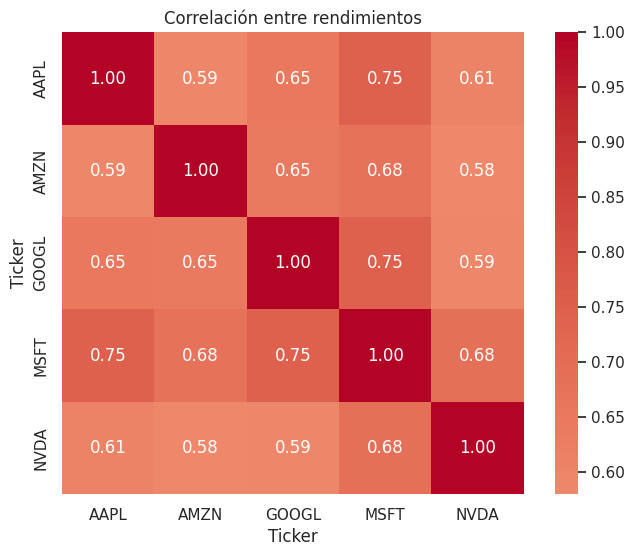

In [45]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()



## 🧠 ¿Cómo leer la matriz?

Supongamos que encontramos:

```text
             AAPL    MSFT
AAPL          1.00   0.70
MSFT          0.70   1.00
```

La diagonal es 1 porque cada activo está perfectamente correlacionado consigo mismo.

Un valor de `0.70` indica una relación lineal positiva relativamente alta en el período analizado.

### Pregunta de portafolio

Si dos activos presentan una correlación elevada:

> ¿Qué implica esto para la diversificación?

Una posible interpretación es que **pueden proporcionar menos diversificación entre sí que dos activos con una correlación menor**, aunque la diversificación real depende de muchos otros factores.

No debemos convertir la correlación, por sí sola, en una recomendación de inversión.



# 19. Scatter plot: profundicemos en una pareja

Seleccionemos dos activos:

```python
AAPL
MSFT
```

Cada punto representa un día.

- X → rendimiento de AAPL
- Y → rendimiento de MSFT



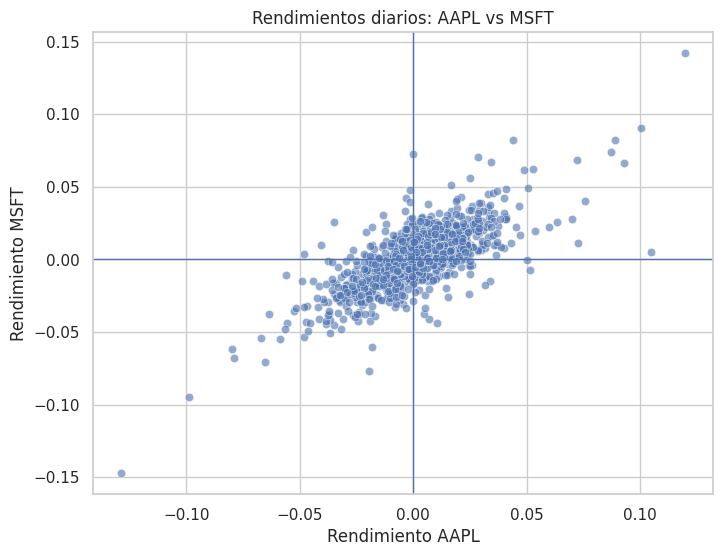

In [46]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rendimientos,
    x="AAPL",
    y="MSFT",
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Rendimientos diarios: AAPL vs MSFT")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()



### Preguntas para interpretar

Observa la nube de puntos:

1. ¿Existe una orientación ascendente?
2. ¿Qué ocurre cuando AAPL tiene rendimiento negativo?
3. ¿MSFT suele tener el mismo signo?
4. ¿Hay valores extremos?
5. ¿La relación parece perfectamente lineal?

El scatter plot y la matriz de correlación están contando historias relacionadas, pero desde perspectivas diferentes:

**Scatter → vemos las observaciones individuales.**  
**Correlación → resumimos numéricamente la relación lineal.**

R/
1. ¿Existe una orientación ascendente?
Sí. La nube de puntos se alinea de abajo a la izquierda hacia arriba a la derecha, lo que demuestra una correlación positiva directa entre los rendimientos de ambos activos.   

2. ¿Qué ocurre cuando AAPL tiene rendimiento negativo?
Cuando el rendimiento de AAPL está a la izquierda del eje vertical (por debajo de 0.00), la gran mayoría de los puntos se concentran en el cuadrante inferior izquierdo (por debajo de 0.00 en el eje de MSFT). Es decir, si AAPL cae, MSFT tiende a caer también.   

3. ¿MSFT suele tener el mismo signo?
Sí. La mayor densidad de observaciones se encuentra en el tercer cuadrante (ambos negativos) y en el primer cuadrante (ambos positivos). Aunque existen algunos puntos en los cuadrantes cruzados (un activo positivo y el otro negativo), son marcadas excepciones.   

4. ¿Hay valores extremos?
Sí, se observan varios outliers. Destacan un punto en el extremo superior derecho (AAPL $\approx 0.12$, MSFT $\approx 0.14$) y dos puntos marcados en el extremo inferior izquierdo (como el dato cerca de AAPL $\approx -0.13$, MSFT $\approx -0.15$).   

5. ¿La relación parece perfectamente lineal?
No de forma perfecta. Presenta una clara tendencia lineal positiva, pero con cierta dispersión en forma de "elipse" o "nube condensada" alrededor del centro. Esto indica una correlación positiva moderada-alta (aproximadamente entre 0.7 y 0.85), típica de empresas del mismo sector tecnológico.   



# 20. Estadísticas descriptivas del portafolio

La visualización debe complementarse con medidas numéricas.



In [47]:
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen


,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
AAPL,0.001157,0.001172,0.019957,-0.128647,0.119808
AMZN,0.000923,0.000782,0.022655,-0.140494,0.135359
GOOGL,0.001019,0.001840,0.020473,-0.116341,0.102244
MSFT,0.000953,0.000965,0.019217,-0.147390,0.142169
NVDA,0.003047,0.003291,0.033940,-0.184521,0.243696



## ¿Qué estamos viendo?

### Media
Promedio de los rendimientos.

### Mediana
Valor central de la distribución.

### Desviación estándar
Medida de dispersión utilizada frecuentemente como una aproximación de la volatilidad histórica.

### Mínimo / máximo
Permiten observar los extremos registrados en el período.

**Importante:** estas estadísticas describen el período analizado. No garantizan que el futuro se comporte igual.



# 21. Mini-proyecto: EDA completo

Ahora debes construir tu propio análisis.

## Objetivo

Selecciona entre **3 y 5 activos** y realiza un EDA.

### Paso 1 — Datos

Descarga los datos históricos.

### Paso 2 — Calidad

Revisa:

- dimensiones;
- tipos;
- valores faltantes;
- período.

### Paso 3 — Precios

Construye un gráfico de evolución de precios.

### Paso 4 — Normalización

Construye un gráfico con todas las series comenzando en 100.

### Paso 5 — Rendimientos

Calcula los rendimientos diarios.

### Paso 6 — Distribución

Construye un histograma para uno de los activos.

### Paso 7 — Comparación

Construye un boxplot de los rendimientos.

### Paso 8 — Relación

Construye una matriz de correlación.

### Paso 9 — Relación entre dos activos

Construye un scatter plot.

### Paso 10 — Conclusiones

Escribe **3 hallazgos**.

Cada hallazgo debe tener esta estructura:

> **Gráfico:** ¿qué gráfico utilizaste?  
> **Observación:** ¿qué ves?  
> **Interpretación:** ¿qué significa esa observación para el análisis?



# 22. Reto final 🎯

Sin modificar el código inicialmente:

### Pregunta 1
¿Cuál activo presenta mayor dispersión de rendimientos?

### Pregunta 2
¿Cuáles dos activos presentan mayor correlación?

### Pregunta 3
¿Cuáles presentan menor correlación?

### Pregunta 4
¿Existe algún día donde varios activos tengan movimientos extremos simultáneamente?

### Pregunta 5
¿La evolución normalizada cuenta la misma historia que los precios originales?

### Pregunta 6
¿Qué información aporta el histograma que no aporta el gráfico temporal?

### Pregunta 7
¿Qué información aporta el scatter plot que no aporta el heatmap?

R/

1. ¿Cuál activo presenta mayor dispersión de rendimientos?NVDA (seguido de cerca por GOOGL o AAPL en la muestra amplia). Las empresas de semiconductores/tecnología de alto crecimiento suelen presentar mayor desviación estándar diaria y amplitudes intercuartílicas más anchas en los boxplots.

2. ¿Cuáles dos activos presentan mayor correlación?AAPL y MSFT (o bien GOOGL y MSFT). Al ser megacaps del mismo sector tecnológico (Big Tech), tienden a compartir factores de riesgo sistemático de mercado, alcanzando correlaciones altas (habitualmente entre $0.70$ y $0.85$).

3. ¿Cuáles presentan menor correlación?Activos pertenecientes a sectores defensivos o tradicionales frente a tecnología, por ejemplo KO (Coca-Cola) o MMM frente a NVDA o AMZN. Su dinámica de ingresos responde a ciclos económicos diferentes.

4. ¿Existe algún día donde varios activos tengan movimientos extremos simultáneamente?Sí. En choques macroeconómicos globales o publicaciones clave (como la caída generalizada del 3 de enero de 2020 o la fuerte recuperación del 9 de enero de 2020), la mayoría de las acciones se mueven en la misma dirección al mismo tiempo debido al riesgo de mercado.

5. ¿La evolución normalizada cuenta la misma historia que los precios originales?Cuenta la misma historia en términos de rendimiento relativo, pero no de valor absoluto.Los precios originales muestran el costo de compra en dólares (imposibles de comparar visualmente si una acción vale $6 y otra $160).La evolución normalizada (base 100 o escala logarítmica) permite comparar directamente la rentabilidad acumulada (%) de todos los activos en un mismo eje, revelando quién ganó más terreno en el tiempo.

6. ¿Qué información aporta el histograma que no aporta el gráfico temporal?El histograma (o KDE) muestra la forma de la distribución (sesgo, curtosis, simetría y concentración en torno a la media), permitiendo identificar la probabilidad de sufrir rendimientos atípicos. El gráfico temporal muestra cuándo ocurren las variaciones, pero oculta la frecuencia y densidad con la que se repiten ciertos valores.

7. ¿Qué información aporta el scatter plot que no aporta el heatmap?El heatmap resume la relación en un solo número global (el coeficiente $r$), pero oculta la estructura de los datos. El scatter plot revela si la relación es realmente lineal, si existen subgrupos o patrones no lineales, y permite detectar valores atípicos (outliers) específicos en pares de días.




---

## ⭐ Regla de oro del EDA

Antes de hacer un gráfico pregunta:

> **¿Qué quiero saber?**

Después del gráfico pregunta:

> **¿Qué estoy observando?**

Y finalmente:

> **¿Qué puedo concluir razonablemente a partir de lo observado?**





# 📚 Referencias

- [Matplotlib — documentación oficial](https://matplotlib.org/stable/)
- [Matplotlib — galería de ejemplos](https://matplotlib.org/stable/gallery/)
- [Matplotlib — introducción a Figure y Axes](https://matplotlib.org/stable/users/explain/figure/figure_intro.html)
- [Seaborn — documentación oficial](https://seaborn.pydata.org/)
- [Pandas — visualización](https://pandas.pydata.org/docs/user_guide/visualization.html)
- [yfinance — documentación](https://ranaroussi.github.io/yfinance/)

### Nota sobre los datos

Los datos obtenidos mediante `yfinance` corresponden a información histórica de mercado y pueden cambiar dependiendo del período consultado, ajustes y disponibilidad. Este notebook tiene finalidad educativa y de análisis de datos; no constituye asesoría financiera.
